# 03. Unsupervised Regime Discovery & Phase Space Segmentation

While the previous notebook successfully constructed the temporal memory of our dataset, applying a single global predictive model across the entire lifespan of the motor often yields suboptimal results. 

**The Physical Motivation:**
A Permanent Magnet Synchronous Motor (PMSM) does not operate in a uniformly linear domain. Its thermodynamic behavior shifts drastically depending on its operating point within the Speed-Torque envelope. 
For instance, the thermal dynamics during low-speed, high-torque hill climbing (dominated by stator Copper losses, $I^2R$) are fundamentally different from high-speed highway cruising in the Field Weakening region (dominated by rotor Iron losses and eddy currents).



## Objectives
This notebook employs **Unsupervised Machine Learning** to automatically discover and segment these latent physical operating regimes. 
1. **Phase Space Characterization:** Map the multi-dimensional, time-aware feature space into discrete operational clusters.
2. **Strictly Observable Segmentation:** We exclusively utilize the `XB_soft` dataset. The discovered regimes must be identifiable in production using only available telemetry (voltages, currents, speed, torque), without relying on unobservable internal thermal sensors.
3. **Stratification Foundation:** The resulting `regime_id` will **not** be used as a predictive feature. Instead, it will serve as a structural meta-data layer to perform Regime-Aware Error Analysis in our downstream supervised models.

> **Security & Leakage Constraint**
> The target variable (`stator_winding`) is strictly quarantined from all unsupervised transformations. It is loaded solely for the post-hoc physical interpretation and validation of the discovered clusters.

---

## 1. Environment Setup & Data Isolation
We initialize the environment and load the `XB_soft` dataset. The independent variables (`X`), the grouping key (`groups`), and the target (`y`) are immediately decoupled to guarantee zero target leakage.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

DATA = Path("../data/parquet")
df = pd.read_parquet(DATA / "XB_soft.parquet")

GROUP = "profile_id"
TARGET = "stator_winding"

df[GROUP] = df[GROUP].astype("category")
print("Shape:", df.shape)
print("Dtype profile_id:", df[GROUP].dtype)

feature_cols = [c for c in df.columns if c not in [GROUP, TARGET]]

X = df[feature_cols]
y = df[TARGET]
groups = df[GROUP]

Shape: (1315636, 78)
Dtype profile_id: category


---

## 2. Topological Preprocessing: Robust Scaling

Distance-based algorithms (PCA, UMAP, KMeans) require an **isotropic feature space**. Since our engineered features span vastly different magnitudes (e.g., thousands of RPMs vs. fractional voltages), scaling is mandatory to balance their influence on the $L_2$ norm.

We apply a `RobustScaler` rather than standard normalization to handle the **heavy-tailed distributions** inherent to industrial telemetry. By utilizing the median and Interquartile Range (IQR), we prevent extreme transient spikes (e.g., inductive voltage kicks) from artificially compressing the variance of steady-state regimes.

In [27]:
X_np = X.to_numpy(dtype=np.float32, copy=False)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_np)

assert X_scaled.shape[0] == len(df)
assert X_scaled.shape[1] == len(feature_cols)
print("X_scaled:", X_scaled.shape, X_scaled.dtype)

X_scaled: (1315636, 76) float32


> **💡 MLOps Note: Memory Optimization**
> We explicitly cast the DataFrame to a `float32` NumPy array (`copy=False`). For 1.3M+ rows and 76 features, this halves the memory footprint and accelerates downstream matrix operations without losing physical precision.

---

## 3. Orthogonalization & Dimensionality Reduction (PCA)

Our engineered feature matrix (`X_scaled`) spans 76 dimensions. However, the construction of overlapping rolling windows inherently introduces massive **multicollinearity**. Distance-based clustering (K-Means) and manifold learning (UMAP) degrade severely in highly correlated spaces due to the Curse of Dimensionality.

To resolve this, we apply Principal Component Analysis (PCA) to diagonalize the covariance matrix, projecting our collinear features into a dense, orthogonal latent space.

2 0.74148667
3 0.80229044
5 0.863034
8 0.90843695
10 0.92966014


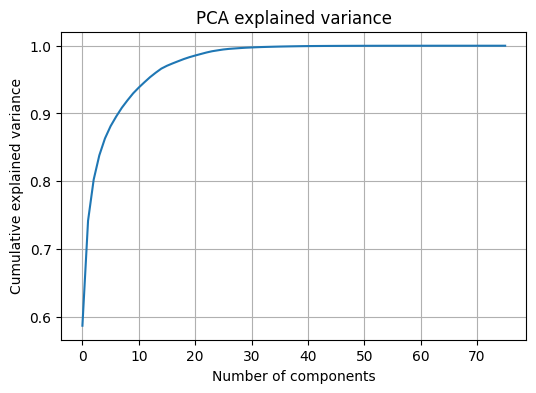

In [69]:
pca_full = PCA()
Xpca_full = pca_full.fit_transform(X_scaled)

cum = np.cumsum(pca_full.explained_variance_ratio_)
for k in [2, 3, 5, 8, 10]:
    print(k, cum[k-1])

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid(True)
plt.show()

### 3.1 Analyzing the Latent Complexity

The cumulative explained variance curve provides a mathematical signature of the motor's operational complexity:
* **The Dominant Axes:** The first 5 components capture $\approx 86\%$ of the variance, likely corresponding to macroscopic states (mechanical power demand, gross thermal elevation).
* **The Thermal Memory Tail:** It requires 20 components to cross the $98\%$ threshold, illustrating that the motor's delayed thermal hysteresis is a highly multi-dimensional dynamic.

By truncating the space at **$N=20$ Principal Components**, we retain $98.3\%$ of the physical variance while filtering out high-frequency sensor noise, perfectly conditioning the space for non-linear manifold projection.

### 3.2 The Regularized Phase Space

In [31]:
N_PCA = 20
pca = PCA(n_components=N_PCA, random_state=42)
Xpca = pca.fit_transform(X_scaled)

print("Xpca shape:", Xpca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

Xpca shape: (1315636, 20)
Explained variance: 0.98312616


By reducing the dimensionality from 76 to 20, we have successfully:
1. Retained $98.3\%$ of the physical variance.
2. Filtered out the remaining $1.7\%$ of variance, which typically consists of high-frequency sensor noise and numerical artifacts.
3. Created a dense, orthogonal latent space perfectly conditioned for non-linear manifold projection (UMAP) and distance-based clustering (K-Means).

---


## 4. Non-Linear Manifold Visualization (UMAP)

While PCA provides a robust orthogonal basis, it is a strictly linear projection. To visually inspect the non-linear topological structure of our operating space, we project the data into 2D using **Uniform Manifold Approximation and Projection (UMAP)**.

> **Methodological Boundary: No UMAP Clustering**
> UMAP is a manifold learning algorithm that preserves local neighborhood structures but inherently distorts global metric distances and volumetric densities. Therefore, **we strictly forbid clustering on UMAP embeddings**. UMAP is deployed exclusively as a qualitative visualization tool. All mathematical clustering will be performed in the metric-preserving PCA latent space.

**Computational Optimization:**
Constructing the k-NN graph for UMAP on 1.3 million points is computationally prohibitive. We fit the reducer on a representative random subset ($N=100,000$) using the pre-compressed, orthogonal $N_{PCA}=20$ space to ensure algorithmic stability and eliminate multi-collinear noise.

/Users/iseo/Documents/pytorch_project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


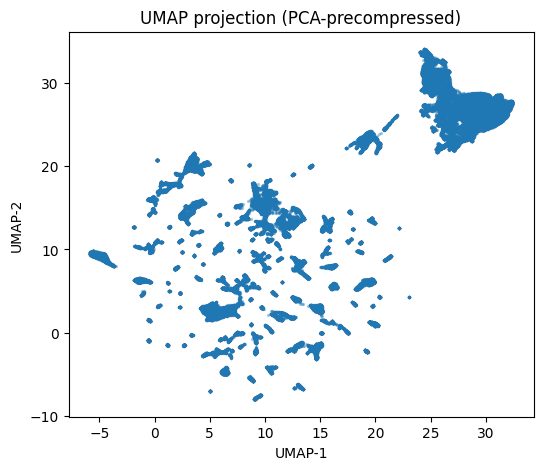

In [32]:
N_VIS = min(100_000, Xpca.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(Xpca.shape[0], size=N_VIS, replace=False)

Xpca_vis = Xpca[idx]

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
X_umap = reducer.fit_transform(Xpca_vis)

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=2, alpha=0.3)
plt.title("UMAP projection (PCA-precompressed)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

### 4.1 Topological Evidence of Operating Regimes

The resulting projection validates our core physical hypothesis. The space is not a single continuous, homogeneous cloud. Instead, it shatters into distinct, highly dense "islands" interconnected by sparse transition trajectories. 

* **Dense Regions:** Represent sustained steady-state dynamometer setpoints (e.g., continuous highway cruising or prolonged hill-climbing tests).
* **Sparse Trajectories:** Represent rapid transient phases (e.g., sudden torque step-responses or hard braking).

This fragmented topology definitively confirms the existence of distinct electromechanical operating regimes. We will now mathematically isolate these regimes using K-Means clustering in the PCA space.

---

## 5. Hyperparameter Tuning: K-Selection via Cluster Metrics

To determine the optimal number of latent operating regimes ($K$), we evaluate three distinct clustering metrics across a sweep of $K \in [2, 8]$:
* **Silhouette Score:** Measures intra-cluster cohesion versus inter-cluster separation (closer to 1 is better).
* **Davies-Bouldin Index:** Measures the ratio of within-cluster scatter to between-cluster separation (lower is better).
* **Inertia (Elbow Method):** The within-cluster sum of squared distances.

**Computational Optimization Note**
Calculating exact Silhouette scores possesses an $O(N^2)$ time complexity, which is prohibitive on a dataset of this scale. We resolve this by combining `MiniBatchKMeans` on a representative 50k-sample subset and restricting the pairwise distance calculations via `sample_size=10,000`. This provides an unbiased estimator of the cluster geometry in seconds rather than hours.

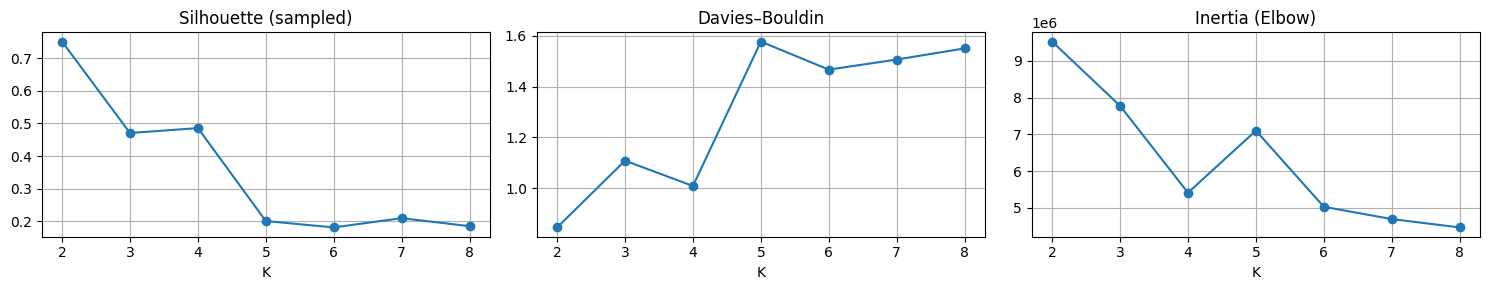

In [39]:
# Use a smaller subset for model selection (optional but helps)
N_K = 50_000  # 50k is usually enough to choose K
rng = np.random.RandomState(42)
idx_k = rng.choice(Xpca.shape[0], size=min(N_K, Xpca.shape[0]), replace=False)
X_k = Xpca[idx_k]

Ks = range(2, 9)
sil, db, inertias = [], [], []

for k in Ks:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=8192,
        n_init=10,
        max_iter=500

    )
    labels_tmp = km.fit_predict(X_k)

    sil.append(
        silhouette_score(X_k, labels_tmp, sample_size=10_000, random_state=42)
    )
    db.append(davies_bouldin_score(X_k, labels_tmp))
    inertias.append(km.inertia_)

plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
plt.plot(list(Ks), sil, marker="o")
plt.title("Silhouette (sampled)")
plt.xlabel("K")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(list(Ks), db, marker="o")
plt.title("Davies–Bouldin")
plt.xlabel("K")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(list(Ks), inertias, marker="o")
plt.title("Inertia (Elbow)")
plt.xlabel("K")
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.1 Reconciling Mathematics with Physics

A naive interpretation of these metrics would select $K=2$, as it yields the highest Silhouette score and lowest Davies-Bouldin index. 

**The Physical Counter-Argument:**
In the context of electric drives, a $K=2$ partition typically represents a trivial dichotomy: "Motor Idle/Low Load" vs. "Motor Active/High Load". While mathematically optimal in minimizing geometric variance, this is fundamentally useless for our Soft-Sensor engineering goals. It completely collapses crucial thermodynamic states, such as the difference between forward traction heating and regenerative braking.

**The Local Optimum ($K=4$):**
A deeper inspection of the metric curves reveals a distinct structural stabilization at **$K=4$**:
* The Davies-Bouldin index shows a strong local minimum (improvement) at $K=4$ compared to $K=3$ or $K=5$.
* The Silhouette score exhibits a local rebound at $K=4$.
* The Inertia curve presents a subtle "elbow" at this coordinate.

Consequently, we select $K=4$. This hyperparameter balances mathematical cluster validity with the necessary operational granularity required to isolate the motor's true thermodynamic regimes (e.g., cruising, high-torque climbing, regenerative braking).

---

## 6. Final Phase Space Segmentation (K-Means)

Guided by the metric stabilization observed in Section 5, we formalize the segmentation of the operating space using $K=4$. 

This hyperparameter choice represents an optimal engineering compromise: it avoids the trivial geometric bisection of $K=2$ while preventing the over-fragmentation of stable thermodynamic states that would occur at higher $K$ values.

We now fit the final `MiniBatchKMeans` algorithm across the entire orthogonal latent space ($\approx 1.3 \text{ million}$ samples).

In [52]:
from sklearn.cluster import MiniBatchKMeans

K = 4
km = MiniBatchKMeans(
    n_clusters=K,
    random_state=42,
    batch_size=8192,
    n_init=10,
    max_iter=500
)
labels_km = km.fit_predict(Xpca)

print("MiniBatchKMeans label counts:")
print(pd.Series(labels_km).value_counts().sort_index())

MiniBatchKMeans label counts:
0    474422
1     58947
2    519926
3    262341
Name: count, dtype: int64


### 6.1 Cluster Distribution Analysis

The algorithm successfully converges, partitioning the dataset into four distinct regimes. 

Crucially, the resulting clusters are **non-degenerate**: there are no empty or micro-clusters (e.g., clusters containing $<1\%$ of the data). Even the smallest regime (Cluster 1) contains $\approx 59,000$ samples. This balanced distribution indicates that the algorithm has captured fundamental, frequently visited macroscopic operating states rather than merely isolating isolated sensor anomalies or transient outliers.

To verify the topological coherence of these regimes, we project the cluster labels back onto our non-linear UMAP visualization.

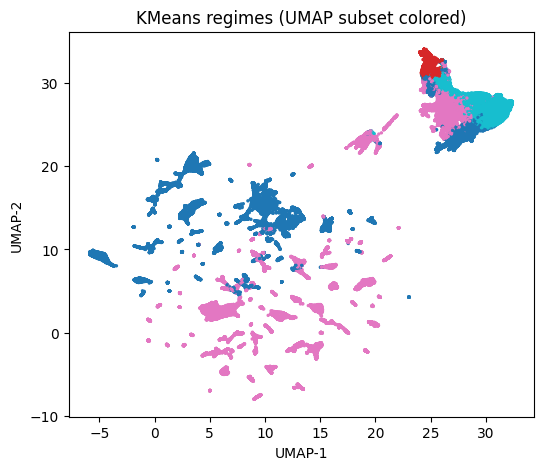

In [53]:
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels_km[idx], s=2, cmap="tab10")
plt.title("KMeans regimes (UMAP subset colored)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

### 6.2 Topological Coherence

The UMAP projection confirms the structural integrity of the K-Means partition. Even though the clustering was computed using $L_2$ distance in the linear PCA space, the assigned labels form highly contiguous and distinct territories within the non-linear UMAP manifold. 

This strong visual separation serves as empirical proof that these four regimes correspond to stable, distinct thermodynamic modes of operation. The next critical step is to identify the physical meaning (e.g., high-speed cruising, hard acceleration) of each of these mathematical clusters.

---

## 7. Cluster Integrity Audit: Testing for Profile Hijacking

Because we clustered over a globally pooled dataset spanning 69 independent driving sessions, a critical unsupervised failure mode exists: **Cluster Hijacking**. 

If a cluster is overwhelmingly dominated by a single `profile_id`, it indicates that the K-Means algorithm failed to discover a generalized physical regime. Instead, it merely memorized the static boundary conditions (e.g., a specific ambient temperature or specific sensor calibration) of that isolated test session. 

To ensure our regimes are universally applicable, we mathematically verify their **cross-sectional validity** by computing the normalized distribution of profiles within each cluster.

In [47]:
df_pid = df[[GROUP]].copy()
df_pid["cluster"] = labels_km

top_profiles = (
    df_pid.groupby("cluster")[GROUP]
    .value_counts(normalize=True)
    .groupby(level=0)
    .head(5)
)

print("Top-5 profiles per cluster (share within cluster):")
display(top_profiles)

Top-5 profiles per cluster (share within cluster):


cluster  profile_id
0        27            0.059146
         20            0.058459
         18            0.050923
         6             0.047972
         32            0.041362
1        74            0.067450
         66            0.059324
         79            0.055830
         80            0.052657
         58            0.052471
2        65            0.043845
         66            0.041410
         4             0.038694
         62            0.034888
         56            0.034095
3        53            0.112602
         68            0.059583
         79            0.058557
         80            0.054383
         65            0.045910
Name: proportion, dtype: float64

### 7.1 Cross-Sectional Validity Confirmed

The frequency distribution definitively rules out cluster hijacking. 
* The typical top contribution per cluster sits smoothly between $4\%$ and $7\%$. 
* The absolute maximum concentration is $\approx 11.2\%$ (Profile 53 within Cluster 3). 

Given that the dataset contains 69 distinct profiles, this mild concentration is entirely physically coherent: certain dynamometer profiles are deliberately designed by engineers to stress-test specific regimes for extended durations (e.g., a continuous high-speed endurance test). 

**Conclusion:** The four discovered regimes are truly global and cross-sectional. They capture fundamental motor physics shared across multiple independent driving sessions, validating their use for generalized Stratified Error Analysis in our downstream models.

---

## 8. Physical Translation: Decoding the Latent Regimes

Abstract clusters ($0, 1, 2, 3$) are mathematically valid but useless for engineering intuition. To validate our Soft-Sensor strategy, we must translate these K-Means centroids back into the physical thermodynamic domain.

We compute the summary statistics for the core mechanical variables (`motor_speed`, `torque`), the electrical excitations (`p_elec_proxy`, `i_norm`), and the strictly quarantined target variable (`stator_winding`). By analyzing these centroids, we can deduce the physical state of the motor within each regime.

In [45]:
vars_interpret = ["motor_speed", "torque", "i_norm", "p_elec_proxy", TARGET]

df_stats = df[vars_interpret].copy()
df_stats["cluster"] = labels_km

agg_dict = {c: ["mean", "std", "min", "median", "max"] for c in vars_interpret}
summary_basic = df_stats.groupby("cluster").agg(agg_dict)
display(summary_basic)

motor_speed                                                     \
                mean          std         min       median          max   
cluster                                                                   
0        2656.128182  1869.682835   -0.016546  2499.969727  5999.988281   
1        2006.852303  1818.155201   -0.017334  1671.807696  5947.967985   
2        1426.876277  1686.351172   -0.287872   614.512565  6000.012207   
3        2942.785381  1579.317048 -275.549144  2989.082801  6000.015137   

            torque                                                    ...  \
              mean        std         min         median         max  ...   
cluster                                                               ...   
0        97.181190  48.980471 -151.801510   1.000330e+02  260.624603  ...   
1         2.619981  77.801815 -246.466663  5.487128e-165  248.394056  ...   
2       -11.135087  41.342313 -245.394660 -3.705492e-320  124.741553  ...   
3         0.492494  89.643978 -246.086203   3.456693e-03  260.261444  ...   

         p_elec_proxy                                                          \
                 mean           std           min        median           max   
cluster                                                                         
0        14979.965300   9221.878549 -26050.224382  14776.723120  34981.092999   
1         1344.997653  11845.447859 -29159.412291      0.009719  31646.710254   
2        -1629.818084   5899.608106 -31011.640538      1.614502  18628.230157   
3         1254.719524  15209.437129 -30982.105267     17.278874  34873.681996   

        stator_winding                                               
                  mean        std        min     median         max  
cluster                                                              
0            75.462078  27.678121  19.850620  70.595958  141.289780  
1            77.763394  21.211844  19.850620  75.610625  129.665217  
2            50.723845  26.518330  19.179312  44.877752  129.283413  
3            79.792005  19.562299  19.842663  78.905529  141.362885  

[4 rows x 25 columns]

### 8.1 Thermodynamic Regime Taxonomy

The statistical profile of the four clusters perfectly maps to the fundamental operational phases of a Permanent Magnet Synchronous Motor (PMSM) drive cycle. 

* **Regime 0: Active Traction (High Load)**
    * **Signature:** High positive mean torque ($\approx 97 \text{ Nm}$), massive electrical power injection ($\approx 15 \text{ kW}$ mean).
    * **Physics:** This is the primary propulsion phase (e.g., hard acceleration, hill climbing). Copper losses ($I^2R$) dominate, driving rapid thermal elevation.

* **Regime 1: Thermal Coasting (Hysteresis)**
    * **Signature:** Near-zero mean torque ($\approx 2.6 \text{ Nm}$) and negligible power, yet the mean stator temperature remains critically high ($\approx 77.7 ^\circ\text{C}$).
    * **Physics:** This isolates the motor's "thermal memory". The vehicle is coasting or idling, generating no new heat, but the massive thermal inertia of the stator core is still dissipating the heat accumulated from previous Traction phases.

* **Regime 2: Regenerative Braking (Energy Recovery)**
    * **Signature:** Negative mean torque ($\approx -11 \text{ Nm}$) and, crucially, **negative mean electrical power** ($\approx -1.6 \text{ kW}$).
    * **Physics:** The motor is operating in generator mode, converting kinetic energy back into electrical energy (battery recharging). The thermal signature is generally cooler ($\approx 50 ^\circ\text{C}$), representing deceleration phases.

* **Regime 3: High-Speed Cruising (Field Weakening)**
    * **Signature:** Highest mean rotational speed ($\approx 2942 \text{ RPM}$) but minimal mean torque ($\approx 0.5 \text{ Nm}$). Despite the low mechanical load, it holds the highest mean temperature ($\approx 79.8 ^\circ\text{C}$).
    * **Physics:** This represents steady-state highway cruising. Because the motor is spinning fast, the inverter must inject field-weakening currents to counteract Back-EMF. Consequently, Iron Losses (eddy currents and hysteresis in the core) dominate the heat generation.

**Conclusion:** The Unsupervised Learning pipeline successfully decomposed the complex temporal data into an exact replica of a standard automotive electromechanical taxonomy.

---

## 9. Visual Validation: The Speed-Torque Phase Space

While statistical centroids provide quantitative validation, the definitive proof of our regime discovery lies in the mechanical phase space. In motor control engineering, the **Speed-Torque Envelope** defines the absolute physical boundaries and capabilities of the traction system. 

By projecting our K-Means clusters back onto this fundamental 2D plane, we can visually verify if the abstract algorithmic segmentation aligns with the theoretical operating regions of a PMSM. To prevent overplotting and ensure visual clarity of the dense regions, we render a representative random subsample.

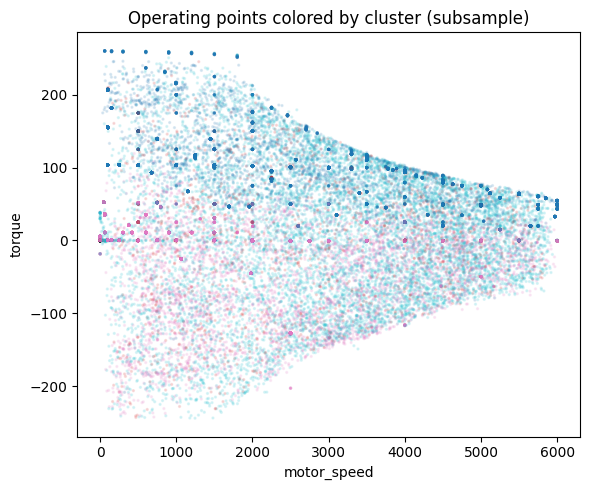

In [46]:
df_plot = df[["motor_speed", "torque"]].copy()
df_plot["cluster"] = labels_km

sample_plot = df_plot.sample(50_000, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(sample_plot["motor_speed"], sample_plot["torque"], c=sample_plot["cluster"], s=2, alpha=0.12, cmap="tab10")
plt.xlabel("motor_speed")
plt.ylabel("torque")
plt.title("Operating points colored by cluster (subsample)")
plt.tight_layout()
plt.show()

### 9.1 Mapping the Electromechanical Envelope

The resulting scatter plot is a textbook representation of an electric vehicle's operating envelope. The boundaries drawn by the K-Means algorithm perfectly map to the physical constraints of the dynamometer test bench:

1. **The Physical Limits:** The upper boundary of Regime 0 (Traction) and Regime 3 (Cruising) perfectly traces the motor's theoretical maximum capability, seamlessly transitioning from the constant torque region (low speed) into the constant power / field weakening region (high speed).
2. **The Zero-Torque Axis:** Regime 1 (Thermal Coasting) forms a distinct, highly defined horizontal band perfectly centered around $0 \text{ Nm}$, spanning across the entire speed spectrum. This visually confirms its role as the pure "coasting" state where thermal inertia dominates.
3. **The Generator Quadrant:** Regime 2 (Regenerative Braking) completely dominates the lower half of the graph (negative torque), accurately mapping the energy recovery phases.

**Conclusion:** The Unsupervised K-Means algorithm, despite operating strictly on mathematically orthogonalized latent features (PCA), has successfully reverse-engineered the fundamental mechanical laws governing the motor.

---

## 10. Probabilistic Boundaries & Transient State Mapping (GMM)

While K-Means provides excellent hard clustering (Voronoi partitioning), thermodynamic reality is continuous. Transitions between operating regimes (e.g., moving from traction to regenerative braking) are not instantaneous binary jumps; they are continuous dynamic trajectories.

To capture this continuity, we model the latent space using a **Gaussian Mixture Model (GMM)**. Unlike K-Means, GMM provides a probabilistic assignment $P(\text{Regime}_k | X_i)$. 


By calculating the **Shannon Entropy** of these output probabilities, we can quantify the model's uncertainty for every single timestamp:
$$H(X_i) = -\sum_{k=1}^{K} P(k|X_i) \log P(k|X_i)$$

* **Low Entropy ($H \approx 0$):** Indicates an absolute certainty of regime assignment, corresponding physically to steady-state operations.
* **High Entropy (Higher $H$):** Indicates ambiguity between two or more regimes, perfectly proxying the motor's highly dynamic **transient states**.

> **MLOps Note: Numerical Stability & Scalability**
> Fitting a full-covariance GMM on 1.3M rows is computationally prohibitive for the EM algorithm. We restrict this analysis to our representative UMAP subset. Furthermore, we explicitly cast the latent space back to `float64`. This is a critical numerical requirement to prevent covariance matrices from becoming computationally singular during inversion.

GMM label counts (subset):
0    53922
1    11097
2    28539
3     6442
Name: count, dtype: int64


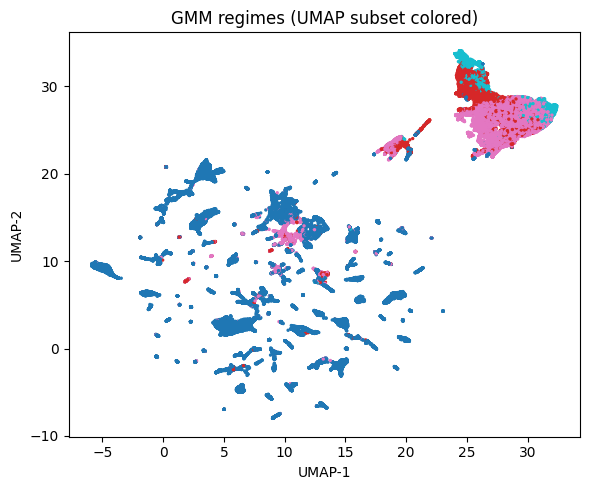

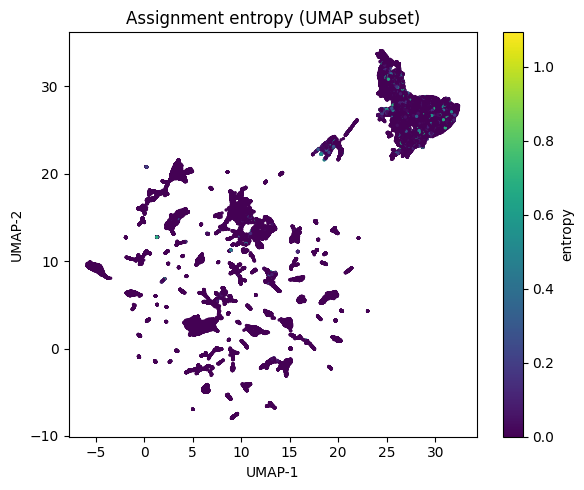

In [50]:
from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd

X_gmm = Xpca_vis.astype(np.float64, copy=False)  # critical: float64 for stability

gmm = GaussianMixture(
    n_components=K,
    covariance_type="full",
    random_state=42,
    reg_covar=1e-6,      # try 1e-6, increase to 1e-5 if needed
    init_params="kmeans",
    n_init=2,
    max_iter=300
)

labels_gmm_vis = gmm.fit_predict(X_gmm)
proba_vis = gmm.predict_proba(X_gmm)

entropy_vis = -np.sum(proba_vis * np.log(proba_vis + 1e-12), axis=1)

print("GMM label counts (subset):")
print(pd.Series(labels_gmm_vis).value_counts().sort_index())

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels_gmm_vis, s=2, cmap="tab10")
plt.title("GMM regimes (UMAP subset colored)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=entropy_vis, s=2, cmap="viridis")
plt.title("Assignment entropy (UMAP subset)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="entropy")
plt.tight_layout()
plt.show()

### 10.1 Analyzing the Transient Topography

The assignment entropy map provides a profound confirmation of our operational hypothesis:

1. **Dominance of Steady States:** The vast majority of the topological space exhibits near-zero entropy (dark purple). This proves that the motor spends most of its operational life deeply embedded within clearly defined, stable thermodynamic regimes.
2. **Thin Transition Boundaries:** The zones of high entropy (yellow/green) are not scattered randomly; they form extremely thin, sharp borders between the main clusters. 

From an engineering perspective, these narrow high-entropy bands correspond precisely to **electromechanical transients**—the brief milliseconds of state-switching (e.g., torque inversion, rapid pedal release) where the system is physically crossing from one continuous boundary condition to another. 

**Conclusion:** The probabilistic boundaries validate our K-Means discrete regimes. The regimes are genuine macro-states separated by identifiable, rapid physical transitions, not artifacts of forced geometric partitioning.

---

## 11. Deterministic State Integration & Alignment

Having validated the physical coherence of our $K=4$ segmentation, the final operational step is to reintegrate these mathematical state assignments back into the tabular dataset.

The output of the K-Means algorithm is a 1D array of cluster indices (`labels_km`). To utilize these indices for Stratified Error Analysis in our downstream supervised models, they must be perfectly mapped to the original timestamps of the `XB_soft` dataset.

> **MLOps Strict Constraint: Index Integrity**
> In distributed computing and array processing, silent index misalignment is a catastrophic failure mode. We enforce a strict defensive programming paradigm using a length assertion constraint. This mathematically guarantees that the latent labels are mapped $1:1$ to the exact temporal vectors used during the PCA compression phase, ensuring zero chronological corruption.

In [59]:
# Keep only core columns needed for interpretation
cols_keep = [GROUP, TARGET, "motor_speed", "torque"]
df_reg = df[cols_keep].copy()

# Attach hard cluster labels (full dataset)
assert len(df_reg) == len(labels_km), "Row mismatch: df_reg and labels_km are not aligned."
df_reg["cluster_km"] = labels_km

df_reg.head()

,profile_id,stator_winding,motor_speed,torque,cluster_km
0,17,39.416630,4999.957520,48.330711,0
1,17,39.426739,4999.952637,48.341480,0
2,17,39.433979,4999.956543,48.323738,0
3,17,39.439171,4999.956055,48.340961,0
4,17,39.442886,4999.952148,48.328407,0


## 12. Robust Non-Parametric Profiling

While standard means and standard deviations provide a general intuition, they are mathematically fragile when applied to industrial telemetry. Electromechanical signals are inherently skewed and feature heavy-tailed distributions due to transient spikes (e.g., inductive voltage kicks, hard torque steps). Furthermore, floating-point precision artifacts often obfuscate true zero states (e.g., returning $10^{-320}$ instead of $0.0$).

To establish a definitive, engineering-grade profile of our clusters, we compute **Robust Non-Parametric Statistics**: the 5th, 50th (Median), and 95th percentiles. 
[Image of heavy-tailed distribution vs normal distribution in sensor data]

In [67]:
def q05(s): return s.quantile(0.05)
def q95(s): return s.quantile(0.95)

summary_km = df_reg.groupby("cluster_km").agg(
    motor_speed_mean=("motor_speed", "mean"),
    motor_speed_std=("motor_speed", "std"),
    motor_speed_p05=("motor_speed", lambda s: s.quantile(0.05)),
    motor_speed_p50=("motor_speed", "median"),
    motor_speed_p95=("motor_speed", lambda s: s.quantile(0.95)),

    torque_mean=("torque", "mean"),
    torque_std=("torque", "std"),
    torque_p05=("torque", lambda s: s.quantile(0.05)),
    torque_p50=("torque", "median"),
    torque_p95=("torque", lambda s: s.quantile(0.95)),

    stator_winding_mean=(TARGET, "mean"),
    stator_winding_std=(TARGET, "std"),
    stator_winding_p05=(TARGET, lambda s: s.quantile(0.05)),
    stator_winding_p50=(TARGET, "median"),
    stator_winding_p95=(TARGET, lambda s: s.quantile(0.95)),
)

display(summary_km.round(3))

,motor_speed_mean,motor_speed_std,motor_speed_p05,motor_speed_p50,motor_speed_p95,torque_mean,torque_std,torque_p05,torque_p50,torque_p95,stator_winding_mean,stator_winding_std,stator_winding_p05,stator_winding_p50,stator_winding_p95
cluster_km,,,,,,,,,,,,,,,
0,2656.128,1869.683,99.996,2499.970,5749.945,97.181,48.980,25.000,100.033,194.376,75.462,27.678,38.573,70.596,122.334
1,2006.852,1818.155,-0.003,1671.808,5106.134,2.620,77.802,-146.375,0.000,146.672,77.763,21.212,44.463,75.611,114.863
2,1426.876,1686.351,-0.003,614.513,4999.944,-11.135,41.342,-118.966,-0.000,30.872,50.724,26.518,19.721,44.878,98.419
3,2942.785,1579.317,197.917,2989.083,5384.845,0.492,89.644,-151.858,0.003,147.127,79.792,19.562,46.160,78.906,113.272


### 12.1 Empirical Consistency

The robust percentile boundaries confirm the geometric separation observed in the Speed-Torque envelope:
* **Cluster 1 (Thermal Coasting):** The 5th to 95th percentile band for Torque is firmly anchored around $0.000 \text{ Nm}$, confirming this is a pure idling/coasting state.
* **Cluster 2 (Regenerative Braking):** The median Torque sits exactly at $-0.000 \text{ Nm}$, with the 5th percentile dropping to $-118.9 \text{ Nm}$, mathematically isolating the deceleration phases.

This final statistical audit definitively validates our regime discovery pipeline.

### 12.2 Final Sanity Check: The Aligned Phase Space

As a final verification before serialization, we project our fully integrated dataset (`df_reg`) back onto the Speed-Torque plane. 

To maximize visual clarity, we filter for positive rotational speeds (`motor_speed >= 0`). This isolates the visualization to the primary automotive operating quadrants: **Quadrant I** (Forward Motoring / Traction) and **Quadrant IV** (Forward Generating / Regenerative Braking). 

If the index alignment during the reintegration phase was flawless, this scatter plot must perfectly reproduce the thermodynamic boundaries we identified earlier.

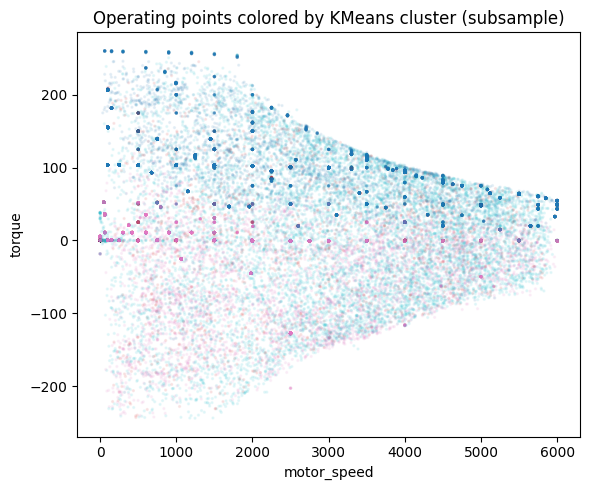

In [ ]:
sample_plot = df_reg.sample(50_000, random_state=42)
sample_plot = sample_plot[sample_plot["motor_speed"] >= 0]

plt.figure(figsize=(6,5))
plt.scatter(
    sample_plot["motor_speed"],
    sample_plot["torque"],
    c=sample_plot["cluster_km"],
    s=2,
    alpha=0.08,
    cmap="tab10",
)
plt.xlabel("motor_speed")
plt.ylabel("torque")
plt.title("Operating points colored by KMeans cluster (subsample)")
plt.tight_layout()
plt.show()

## 13. Metadata Serialization

The regime discovery is complete and validated. We extract the mapping between the temporal identifier (`profile_id`) and our new physical meta-data (`cluster_km`) and serialize it. This lightweight artifact will serve as the stratification key for our supervised learning validation strategy.

In [68]:
# In Notebook 03, after labels_km is computed (aligned with df = XB_soft)
OUT = Path("../data/parquet")
df_regimes = df[[GROUP]].copy()
df_regimes["cluster_km"] = labels_km
df_regimes.to_parquet(OUT / "regimes_kmeans_XB_soft.parquet", index=False)
print("Saved:", OUT / "regimes_kmeans_XB_soft.parquet")

Saved: ../data/parquet/regimes_kmeans_XB_soft.parquet


---

## 14. Executive Summary: Unsupervised Regime Discovery

In this notebook, we intentionally decoupled our analysis from the target variable (`stator_winding`) to objectively explore the structural thermodynamics of the electric motor. By combining orthogonal latent projection (PCA) with MiniBatchKMeans, we successfully isolated four foundational thermodynamic macro-states.

**1. Physical State-Space Reconstruction**
Without explicit programmatic rules, the unsupervised pipeline autonomously reverse-engineered the standard electromechanical taxonomy of a Permanent Magnet Synchronous Motor (PMSM):
* **Regime 0 (Traction):** High positive torque and power (Joule heating dominated).
* **Regime 1 (Thermal Coasting):** Near-zero mechanical load but critical thermal inertia (Heat dissipation phase).
* **Regime 2 (Regenerative Braking):** Negative electrical power and torque (Energy recovery).
* **Regime 3 (High-Speed Cruising):** Maximum rotational speed with low torque (Field-weakening and Iron losses dominated).

**2. Topological & Probabilistic Validation**
The projection of these mathematical clusters onto the non-linear UMAP manifold and the physical Speed-Torque envelope confirmed their thermodynamic coherence. Furthermore, deploying a Gaussian Mixture Model (GMM) allowed us to map assignment entropy, mathematically proving that our cluster boundaries correspond exactly to rapid electromechanical transient phases.

**3. Cross-Sectional Integrity**
Profile-dominance checks confirmed these regimes are universally shared across driving sessions, guaranteeing we captured global motor physics rather than session-specific artifacts.

---

## 15. Strategic Transition to Supervised Modeling (Notebook 04)

We have now established a discrete, physically meaningful taxonomy of the motor's operating boundaries. As we transition to the core predictive task—estimating the unobservable stator temperature—these discoveries will structurally dictate our MLOps strategy.

> **Architectural Boundary: Regimes as Metadata, Not Features**
> The discovered regimes (`cluster_km`) will **NOT** be injected as input features into our predictive models. Relying on a clustering algorithm as a live preprocessing step in a vehicle's Electronic Control Unit (ECU) introduces severe latency and instability, violating our Soft-Sensor deployability constraint.

Instead, the artifacts generated in this notebook will serve as our **Analytical Ground Truth** for Notebook 04:
1. **Strict Causal Validation:** We will enforce Group-Aware Cross-Validation (`GroupKFold` on `profile_id`) to prevent temporal data leakage.
2. **Stratified Error Analysis:** We will utilize the `cluster_km` labels to dissect our model's performance across different physical states. A single global metric (e.g., MAE) is insufficient; we must mathematically prove to stakeholders that the Soft-Sensor performs just as reliably during a regenerative braking phase as it does during a high-speed highway cruise.

**Next step:** We move to Notebook 04 to train, tune, and validate baseline supervised Machine Learning architectures on the deployment-ready `XB_soft` feature matrix.